# Feature Selection


Define and implement a clear and unambiguous strategy for feature selection. Use the methods
discussed in the course. Present and justify your final selection.


Goal:
We will now start the feature selection process on the fully encoded and scaled data.
In this step, we simply load the processed datasets that were saved in the previous notebook (12_data_imputation_and_encoding.ipynb).

# Table of Contents

<a id="top"></a>

1. [Import Libraries](#sec-1-imports) <br>
2. [Load Dataset](#sec-2-load) <br>
3. [Sanity Checks and Feature Lists](#sec-3-sanity) <br>
4. [Filter Methods](#sec-4-filter) <br>
   &emsp; 4.1 [Variance Threshold (Constant/Quasi-constant)](#sec-4-1-variance) <br>
   &emsp; 4.2 [Correlation Analysis (Pearson, Spearman, Kendall)](#sec-4-2-correlation) <br>
5. [Wrapper Methods](#sec-5-wrapper) <br>
   &emsp; 5.1 [Recursive Feature Elimination (RFE)](#sec-5-1-rfe) <br>
6. [Final Insights](#sec-6-insights) <br>



<a id="sec-1-imports"></a>
## 1. Import Libraries


In [28]:
# --- Imports ---
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.base import clone



<a id="sec-2-load"></a>
## 2. Load Dataset


In [2]:

# --- Define paths ---
data_dir = "../data/"
encoded_dir = os.path.join(data_dir, "encoded_data")

# --- Load encoded & scaled datasets ---
X_train = pd.read_csv(os.path.join(encoded_dir, "12_X_train.csv"))
y_train = pd.read_csv(os.path.join(encoded_dir, "12_y_train.csv")).squeeze()

X_val = pd.read_csv(os.path.join(encoded_dir, "12_X_val.csv"))
y_val = pd.read_csv(os.path.join(encoded_dir, "12_y_val.csv")).squeeze()

X_test = pd.read_csv(os.path.join(encoded_dir, "12_X_test.csv"))

# --- Sanity checks ---
print("Encoded datasets successfully loaded!")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}")



Encoded datasets successfully loaded!
X_train shape: (56979, 20)
y_train shape: (56979,)
X_val shape:   (18994, 20)
y_val shape:   (18994,)
X_test shape:  (32567, 20)


<a id="sec-3-sanity"></a>
## 3. Sanity Checks and Feature Lists


In [3]:
# Missing values
def has_missing(name, X):
    n = int(X.isna().sum().sum())
    print(f"[{name}] total NaNs: {n}")
    return n

_ = has_missing("X_train", X_train)
_ = has_missing("X_val",   X_val)
_ = has_missing("X_test",  X_test)


[X_train] total NaNs: 0
[X_val] total NaNs: 0
[X_test] total NaNs: 0


In [4]:
# very simple feature groups (vertical)
assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns)

te = [c for c in ("Brand", "model") if c in X_train.columns]
ohe = [c for c in X_train.columns if set(X_train[c].dropna().unique()).issubset({0, 1})]
cont = [c for c in X_train.columns if c not in ohe + te]

print(f"Total: {len(X_train.columns)}\n")
print("OHE-like:")
print("\n".join(f"  - {c}" for c in ohe) or "  - -")
print("\nTarget-encoded:")
print("\n".join(f"  - {c}" for c in te) or "  - -")
print("\nContinuous:")
print("\n".join(f"  - {c}" for c in cont) or "  - -")


Total: 20

OHE-like:
  - hasDamage
  - transmission_automatic
  - transmission_other
  - transmission_semi-auto
  - transmission_unknown
  - fuelType_diesel
  - fuelType_electric
  - fuelType_hybrid
  - fuelType_other

Target-encoded:
  - Brand
  - model

Continuous:
  - year
  - mileage
  - tax
  - mpg
  - engineSize
  - paintQuality%
  - previousOwners
  - transmission_manual
  - fuelType_petrol


<a id="sec-4-filter"></a>
## 4. Filter Methods


We start with Filter methods, because they are computationally inexpensive and helpful for an initial screening of features. 

<a id="sec-4-1-variance"></a>
### 4.1 Variance Threshold (Constant or Quasi-constant)


1. **Setting a Variance Threshold** - useful to deal with features that are constant or quasi-constant - thus, unlikely to be **relevant**


In [5]:
# compute population variance, round for readability, sort by variance desc

X_train.var(ddof=0).round(6).sort_values(ascending=False)


tax                       9.701211
mpg                       1.206218
mileage                   0.808560
previousOwners            0.525891
year                      0.521331
model                     0.518981
engineSize                0.502169
paintQuality%             0.352750
Brand                     0.285914
fuelType_petrol           0.246273
transmission_manual       0.244768
fuelType_diesel           0.241522
transmission_semi-auto    0.170670
transmission_automatic    0.159696
fuelType_hybrid           0.027971
transmission_unknown      0.009646
fuelType_other            0.002172
transmission_other        0.000088
fuelType_electric         0.000053
hasDamage                 0.000000
dtype: float64

We can see, that the Feature hasDamage, fuelType_electric and transmission_other is = 0 or close to 0 variance, meaning it is constant and can be removed.

In [6]:
# Remove the Feature 'hasDamage', 'fuelType_electric' and 'transmission_other' due to 0 variance across all samples.
X_train = X_train.drop(columns=["hasDamage", "fuelType_electric", "transmission_other"])
X_val   = X_val.drop(columns=["hasDamage", "fuelType_electric", "transmission_other"])
X_test  = X_test.drop(columns=["hasDamage", "fuelType_electric", "transmission_other"])

<a id="sec-4-2-correlation"></a>
### 4.2 Correlation Analysis (Pearson, Spearman, Kendall Tau)


We have to analyze the Correlation of the features to find things about the relevance and redundancy of the features


1. Select **relevant** features - Correlation with the target (the higher the correlation in absolute value, the more relevant the feature seems to be) 
2. Exclude **redundant** features - Correlation between features (the higher the correlation in absolute value, the more redundant the feature)

For that we will use pearson for linear correlation, spearman and kendall tau for monotonic but non linear relationships and summarize our findings. We dont use Cramers V becuase we have numeric features.

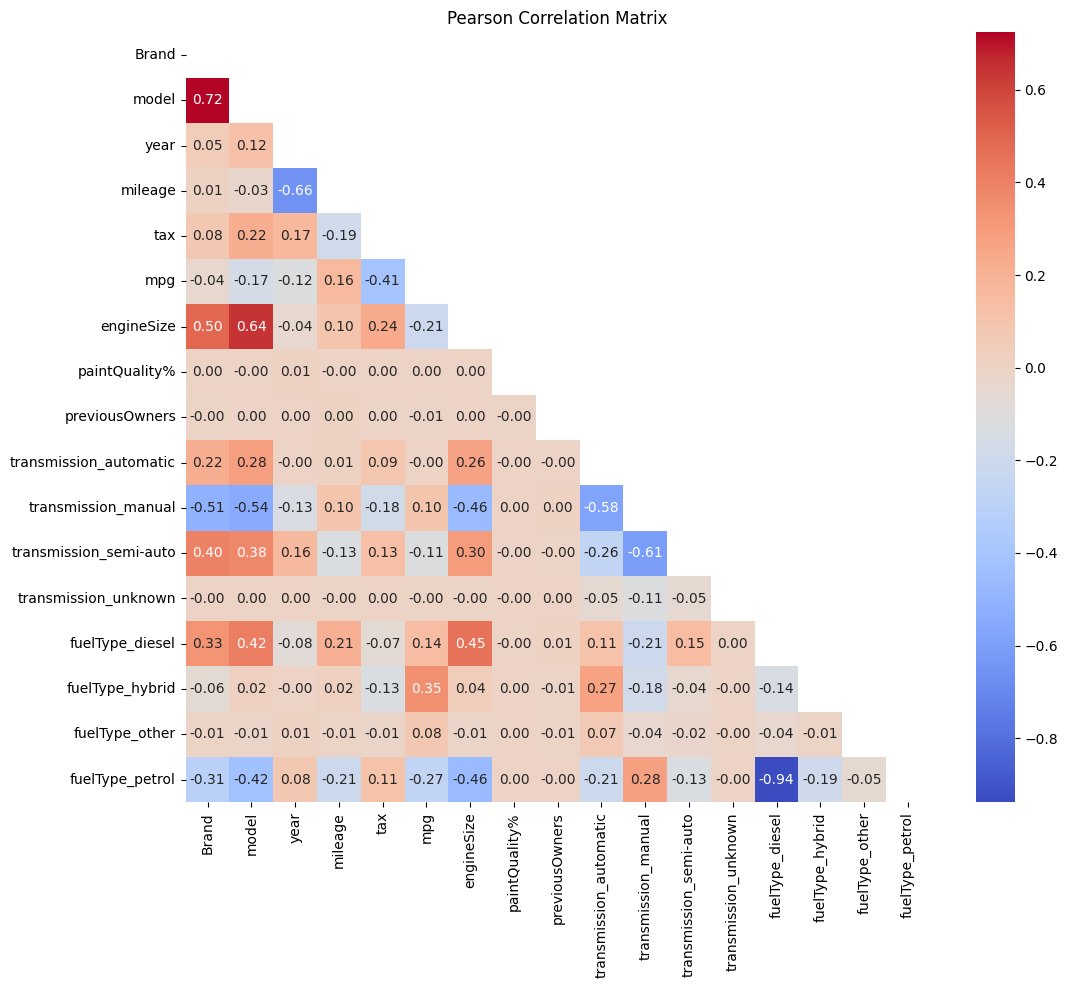

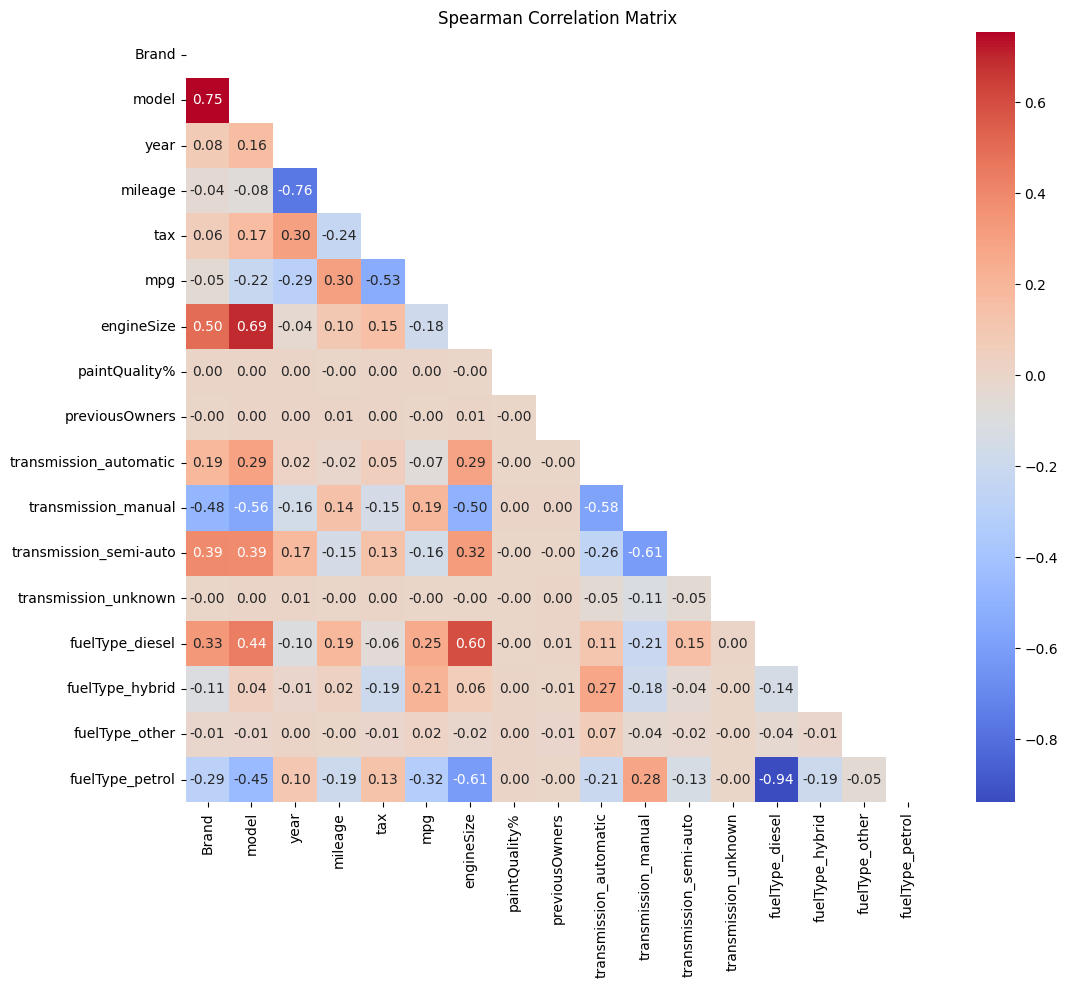

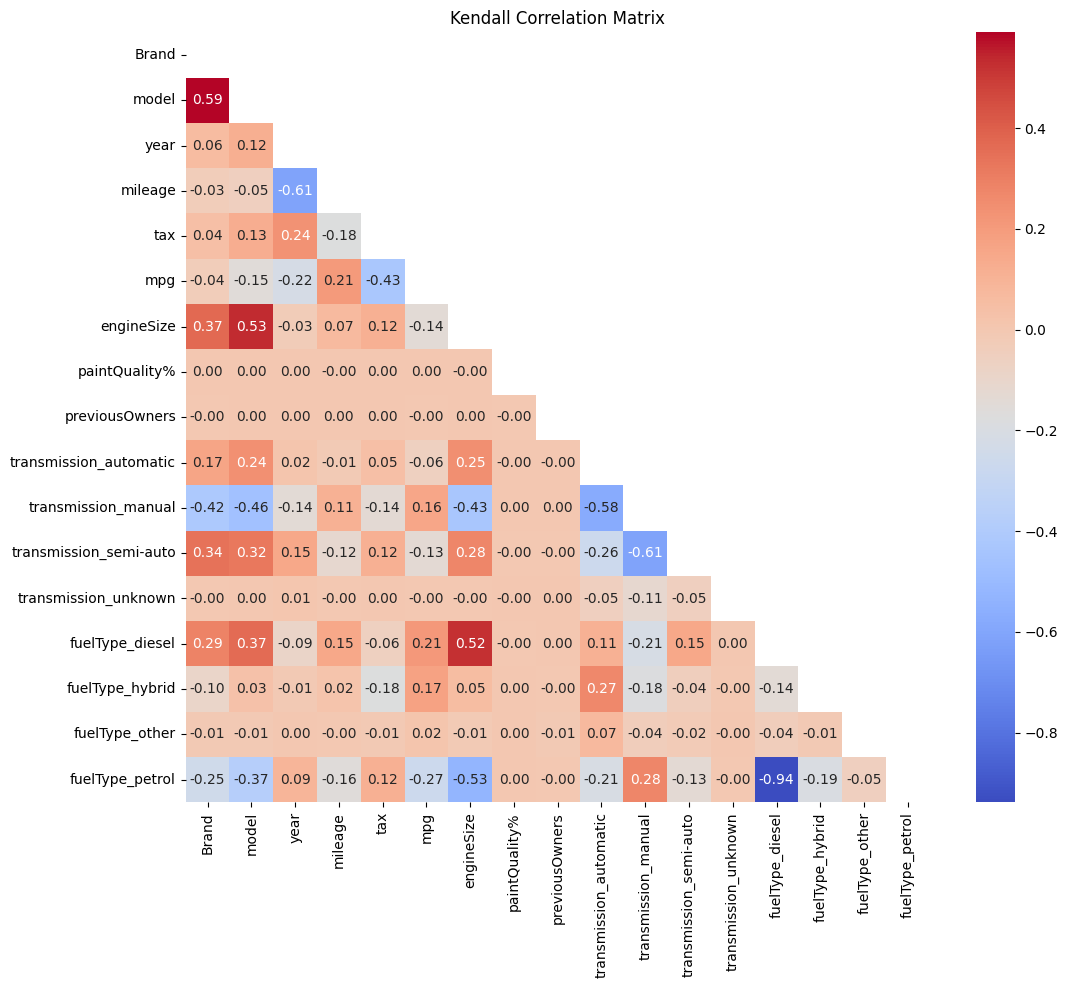

In [7]:
# Pearson, Spearman and Kendall Tau Correlation 

methods = ["pearson", "spearman", "kendall"]

for method in methods:
    cor = X_train.corr(method=method)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cor, annot=True, fmt=".2f", cmap='coolwarm', mask=np.triu(cor))
    plt.title(f'{method.capitalize()} Correlation Matrix')
    plt.show()


- At this point we can see, that the correlation between Brand and model is the highest in all 3 methods. We can consider to remove one of them in the next steps, but the correlation is lower than 0.8. So we will keep both for now. 

- when we want to remove it, we have to find a method to choose which one to remove. For example we can check the correlation of each feature with the target and remove the one with the lower correlation.

<a id="sec-5-wrapper"></a>
## 5. Wrapper Methods


There are different types of Wrapper Methods, we will use Recursive Feature Elimination (RFE) in this case.

- Exhaustive Feature, Forward Feature Selection, Backward Feature Elimination: These methods are computationally expensive and not feasible for datasets with a large number of features.
- Recursive Feature Elimination (RFE): We will use this method because it is computationally efficient and can effectively identify the most relevant features by recursively eliminating the least important ones based on model performance.

<a id="sec-5-1-rfe"></a>
### 5.1 Recursive Feature Elimination (RFE)


- Right now we have 19 Features after removing constant and quasi-constant features.
- We dont know what number of features it the optimal one for our model.
- That is why we create a loop to check the optimal number of features from 1 to 19.

In [37]:
# --- Wrapper Methods: Recursive Feature Elimination (RFE) ---
# Using different models for RFE
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1, max_iter=5000),
    }


# --- Store results here ---
results = {}

# --- Run RFE for each model ---
nof_list = np.arange(1, len(X_train.columns) + 1)
step = max(1, len(X_train.columns)//10)

for name, base_model in models.items():
    print(f"\n===== {name} =====")
    train_scores, val_scores = [], []
    best_score = -np.inf
    best_n = 0

    for n in nof_list:
        rfe = RFE(estimator=base_model, n_features_to_select=n, step=step)
        X_train_rfe = rfe.fit_transform(X_train, y_train)
        X_val_rfe   = rfe.transform(X_val)
        model = base_model.fit(X_train_rfe, y_train)

        tr = model.score(X_train_rfe, y_train)
        va = model.score(X_val_rfe, y_val)
        train_scores.append(tr)
        val_scores.append(va)

        if va >= best_score:
            best_score = va
            best_n = n

    results[name] = {"train": train_scores, "val": val_scores, "nof": best_n}
    print(f"Best features: {best_n} | Best val score: {best_score:.4f}")



===== LinearRegression =====
Best features: 16 | Best val score: 0.7735

===== Ridge =====
Best features: 16 | Best val score: 0.7735

===== Lasso =====
Best features: 14 | Best val score: 0.7735


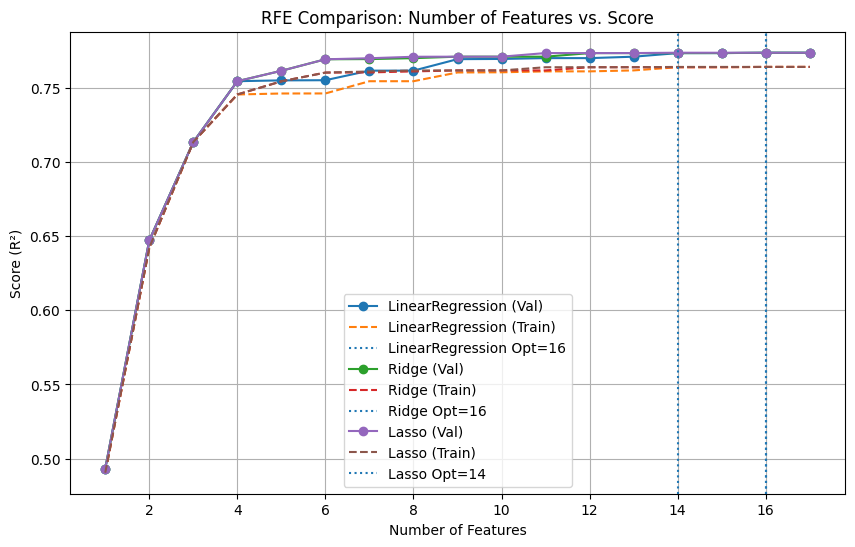

In [38]:
# --- Plot all models together ---
plt.figure(figsize=(10, 6))

for name, data in results.items():
    plt.plot(nof_list, data["val"], marker='o', label=f'{name} (Val)')
    plt.plot(nof_list, data["train"], linestyle='--', label=f'{name} (Train)')
    plt.axvline(x=data["nof"], linestyle=':', label=f'{name} Opt={data["nof"]}')

plt.title("RFE Comparison: Number of Features vs. Score")
plt.xlabel("Number of Features")
plt.ylabel("Score (R²)")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
# Display the selected features for Linear Regression with optimal number of features
model = LinearRegression()
nof = results["LinearRegression"]["nof"]

rfe = RFE(estimator=model, n_features_to_select=nof)
X_rfe = rfe.fit_transform(X_train, y_train)
selected_features = X_train.columns[rfe.support_]
print("Selected features:")
for feature in selected_features:
    print(f" - {feature}")

plt.show()

Selected features:
 - Brand
 - model
 - year
 - mileage
 - tax
 - mpg
 - engineSize
 - paintQuality%
 - transmission_automatic
 - transmission_manual
 - transmission_semi-auto
 - transmission_unknown
 - fuelType_diesel
 - fuelType_hybrid
 - fuelType_other
 - fuelType_petrol


In [41]:
# Create subset for X_train and y_train for better performance during feature selection
X_train_subset = X_train.sample(n=1000, random_state=42)
y_train_subset = y_train.loc[X_train_subset.index] 
X_val_subset = X_val.sample(n=200, random_state=42)
y_val_subset = y_val.loc[X_val_subset.index]

In [42]:
#no of features
nof_list=np.arange(1,len(X_train_subset.columns)+1)            
high_score=0
#Variable to store the optimum features
nof=0           
train_score_list =[]
val_score_list = []

for n in range(len(nof_list)):
    model = RandomForestRegressor()

    rfe = RFE(estimator=model, n_features_to_select=nof_list[n])
    X_train_rfe = rfe.fit_transform(X_train_subset, y_train_subset)
    X_val_rfe = rfe.transform(X_val_subset)
    model.fit(X_train_rfe, y_train_subset)

    #storing results on training data
    train_score = model.score(X_train_rfe, y_train_subset)
    train_score_list.append(train_score)
    
    #storing results on validation data
    val_score = model.score(X_val_rfe, y_val_subset)
    val_score_list.append(val_score)
    
    #check best score
    if(val_score >= high_score):
        high_score = val_score
        nof = nof_list[n]
print("Optimum number of features: %d" %nof)
print("Score with %d features: %f" % (nof, high_score))

Optimum number of features: 16
Score with 16 features: 0.898253


<a id="sec-6-insights"></a>
## 6. Final Insights


Need to be adapted based on the final results of the feature selection process.

<hr>

### Numerical Data

| Predictor | Spearman | RFE LR| RFE SVM | Lasso | What to do? (One possible way to "solve") | 
| --- | --- | --- | --- |--- |---|
| Age | Keep | Keep | Keep |Keep | Include in the model |
| Fare | Keep | Keep | Keep |Keep| Include in the model |
| Parch | Keep?| Discard | Discard |Keep ?| Discard |
| PClass | Keep | Keep | Keep | Keep | Include in the model |
| SibSp | Keep? | Discard | Keep | Keep | Keep |
| Family_Size | Keep? | Discard | Discard | Keep | Discard |
| Embark_Hour | Keep |Discard |Keep | Keep? |  Try with and without |

<hr>